In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('placement.csv')
print(data.head())

   Student_ID  CGPA  Internships Placed  Salary (INR LPA)
0           1  7.90            3    Yes             17.63
1           2  7.39            0    Yes             28.37
2           3  8.02            2    Yes              8.95
3           4  8.72            4    Yes             22.59
4           5  7.31            2    Yes             19.67


In [3]:
# Check column names and types
print(data.info())

# Check for missing values
print(data.isnull().sum())

# Basic statistics of numeric columns
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   int64  
 1   CGPA              1000 non-null   float64
 2   Internships       1000 non-null   int64  
 3   Placed            1000 non-null   object 
 4   Salary (INR LPA)  1000 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 39.2+ KB
None
Student_ID          0
CGPA                0
Internships         0
Placed              0
Salary (INR LPA)    0
dtype: int64
        Student_ID         CGPA  Internships  Salary (INR LPA)
count  1000.000000  1000.000000  1000.000000       1000.000000
mean    500.500000     7.515560     2.045000         11.795580
std     288.819436     0.783422     1.424431         10.105559
min       1.000000     4.910000     0.000000          0.000000
25%     250.750000     6.980000     1.000000          0.0000

In [5]:
from sklearn.model_selection import train_test_split

# Features (input variables)
X = data.drop("Placed", axis=1)

# Target (output variable)
y = data["Placed"]

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 4)
X_test shape: (200, 4)
y_train shape: (800,)
y_test shape: (200,)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
model = RandomForestClassifier()

# Train model
model.fit(X_train, y_train)

# Predict using test data
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

# Detailed evaluation
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        62
         Yes       1.00      1.00      1.00       138

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [14]:
import pandas as pd

# Check the training feature columns
feature_cols = X.columns.tolist()
print("Feature columns:", feature_cols)

# Create new student data as a DataFrame with correct column names
new_student = pd.DataFrame([[8.2, 1, 3, 2]], columns=feature_cols)

# Make prediction
prediction = model.predict(new_student)

# Display result
if prediction[0] == 1:
    print("Student will be Placed")
else:
    print("Student will NOT be Placed")

Feature columns: ['Student_ID', 'CGPA', 'Internships', 'Salary (INR LPA)']
Student will NOT be Placed


Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

          No       1.00      1.00      1.00        62
         Yes       1.00      1.00      1.00       138

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Confusion Matrix:
 [[ 62   0]
 [  0 138]]


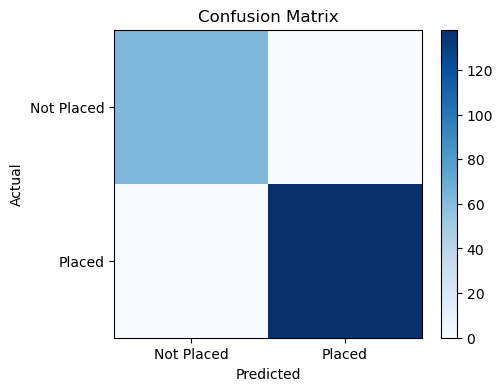

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1️⃣ Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# 2️⃣ Detailed Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 3️⃣ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Optional: Visualize confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.xticks([0,1], ["Not Placed", "Placed"])
plt.yticks([0,1], ["Not Placed", "Placed"])
plt.show()

In [16]:
import pandas as pd

# Feature columns used for training
feature_cols = X.columns.tolist()

# Example: Predict multiple students at once
new_students = pd.DataFrame([
    [8.2, 1, 3, 2],   # Student 1
    [7.0, 0, 1, 1],   # Student 2
    [9.0, 1, 4, 3]    # Student 3
], columns=feature_cols)

# Make predictions
predictions = model.predict(new_students)

# Display results
for i, pred in enumerate(predictions):
    status = "Placed" if pred == 1 else "Not Placed"
    print(f"Student {i+1}: {status}")

Student 1: Not Placed
Student 2: Not Placed
Student 3: Not Placed


In [18]:
# Ask user to input new student data
cgpa = float(input("Enter CGPA: "))
internship = int(input("Internship done? 1=Yes, 0=No: "))
projects = int(input("Number of Projects: "))
communication = int(input("Communication Skill Score: "))

new_student = pd.DataFrame([[cgpa, internship, projects, communication]], columns=feature_cols)
prediction = model.predict(new_student)

print("Prediction:", "Placed" if prediction[0] == 1 else "Not Placed")

Enter CGPA:  9.6
Internship done? 1=Yes, 0=No:  1
Number of Projects:  9
Communication Skill Score:  200


Prediction: Not Placed


In [19]:
data.to_csv("student_placement_predictions.csv", index=False)